# OneLand — Assignment over handmade chains

Pick one full-tile chain per tile from `handmade_dp_candidates.json` (Coupled-Open / OneLand constraints).

- **25 tiles** — one NW 5×5 land
- **4 workers** — farmer + 3 daily hires (fib cost 1+1+2 = $4/day)
- **Zone ops caps** — farmer 15, hire1 13, hire2 13, hire3 11 (after zone traversal)
- **Open** wheat/fertilizer — buy shortfall at I0 ($25 / $100)
- **Cash** — $3000 starting bank, never negative
- **Assignment** — CP-SAT uses per-zone chain **counts** (`count[zone][chain]`), then decodes to tiles (tiles within a zone are interchangeable)
- **PICKUP ops in master** (not in rollout JSON): +1 animal PICKUP on placement; +1 wheat PICKUP per FEED tile; +1 fert PICKUP on FERTILIZE
- **Hire preamble** (+1 wheat PICKUP when hire zone has active animals): zone-scoped 0/1 in master


In [1]:
import json

from ortools.sat.python import cp_model

In [2]:
import resource
import tracemalloc
from functools import wraps

def peak_mem(fn):
    @wraps(fn)
    def wrapper(*args, **kwargs):
        rss_before = resource.getrusage(resource.RUSAGE_SELF).ru_maxrss
        tracemalloc.start()
        try:
            return fn(*args, **kwargs)
        finally:
            _, peak = tracemalloc.get_traced_memory()
            tracemalloc.stop()
            rss_after = resource.getrusage(resource.RUSAGE_SELF).ru_maxrss
            print(
                f"{fn.__name__}: "
                f"tracemalloc peak={peak / 1e6:.1f} MB, "
                f"RSS max={rss_after / 1024:.1f} MB "
                f"(was {rss_before / 1024:.1f} MB)"
            )
    return wrapper


In [3]:
with open("../data/crop_rollouts.json", "r") as f:
    crops_data = json.load(f)
with open("../data/animal_rollouts.json", "r") as f:
    animals_data = json.load(f)
with open("../data/handmade_dp_candidates.json", "r") as f:
    handmade_chains = json.load(f)


In [4]:
NUM_DAYS = 30
NUM_TILES = 25
BUILD_DAY_OFFSET = animals_data["meta"].get("build_day_offset", -1)
WHEAT_PRICE = 25
FERT_PRICE = 100
MAX_BUY = NUM_TILES * NUM_DAYS
STARTING_MONEY = 3000
HIRE_DAILY_COST = 1 + 1 + 2  # always hire 3 hands (fib)

WORKERS = ("farmer", "hire1", "hire2", "hire3")
HAND_WORKERS = ("hire1", "hire2", "hire3")
WORKER_TILES = {
    "farmer": list(range(0, 9)),
    "hire1": list(range(9, 15)),
    "hire2": list(range(15, 21)),
    "hire3": list(range(21, 25)),
}
NET_TILE_OPS = {"farmer": 15, "hire1": 13, "hire2": 13, "hire3": 11}

TILE_WORKER = (
    ["farmer"] * len(WORKER_TILES["farmer"])
    + ["hire1"] * len(WORKER_TILES["hire1"])
    + ["hire2"] * len(WORKER_TILES["hire2"])
    + ["hire3"] * len(WORKER_TILES["hire3"])
)

PROFILE_SUFFIXES = ("no_fert", "with_fert", "no_care", "with_care")

ZERO_DAILY = {
    "daily_tile_ops": [0] * NUM_DAYS,
    "daily_wheat_pickup": [0] * NUM_DAYS,
    "daily_animal_place": [0] * NUM_DAYS,
    "daily_animal_active": [0] * NUM_DAYS,
    "daily_fert_pickup": [0] * NUM_DAYS,
    "daily_feed": [0] * NUM_DAYS,
    "daily_fert": [0] * NUM_DAYS,
    "daily_collect": [0] * NUM_DAYS,
    "daily_wheat": [0] * NUM_DAYS,
}


def worker_for_tile(tile: int) -> str:
    return TILE_WORKER[tile]


def parse_profile_key(profile_key: str):
    for suffix in PROFILE_SUFFIXES:
        token = f"_{suffix}"
        if profile_key.endswith(token):
            return profile_key[: -len(token)], suffix
    raise ValueError(f"unknown profile key: {profile_key}")


def rollout_spec(label: str, profile_name: str):
    if label in crops_data["crops"]:
        spec = crops_data["crops"][label]
        return "crop", spec, spec[profile_name]
    if label in animals_data["animals"]:
        spec = animals_data["animals"][label]
        return "animal", spec, spec[profile_name]
    raise KeyError(label)


def parse_age_maps(profile, label, kind):
    harvest_map = dict(zip(profile["harvest_ages"], profile["yield_per_harvest"]))
    feed_by_age = {}
    fert_use_by_age = {}
    collect_by_age = {}
    wheat_gain_by_age = {}
    for day in profile["days"]:
        age = day["age"]
        acts = day["actions"]
        feed_by_age[age] = 1 if "FEED" in acts else 0
        fert_use_by_age[age] = 1 if "FERTILIZE" in acts else 0
        collect_by_age[age] = 1 if "COLLECT_FERTILIZER" in acts else 0
        if kind == "crop" and label == "WHEAT" and age in harvest_map:
            wheat_gain_by_age[age] = harvest_map[age]
        else:
            wheat_gain_by_age[age] = 0
    return feed_by_age, fert_use_by_age, collect_by_age, wheat_gain_by_age


def build_cash_by_day(start_day, setup_cost, base_price, profile):
    cash = [0] * NUM_DAYS
    cash[start_day] -= setup_cost
    for age, yld in zip(profile["harvest_ages"], profile["yield_per_harvest"]):
        hday = start_day + age
        if hday < NUM_DAYS:
            cash[hday] += yld * base_price
    return cash


def stamp_placement(profile_key: str, start_day: int):
    label, profile_name = parse_profile_key(profile_key)
    kind, spec, profile = rollout_spec(label, profile_name)
    setup_cost = spec["seed_cost"] if kind == "crop" else spec["animal_cost"]
    base_price = spec["base_price"]
    feed_by_age, fert_use_by_age, collect_by_age, wheat_gain_by_age = parse_age_maps(
        profile, label, kind
    )

    daily_tile_ops = [0] * NUM_DAYS
    daily_wheat_pickup = [0] * NUM_DAYS
    daily_animal_place = [0] * NUM_DAYS
    daily_animal_active = [0] * NUM_DAYS
    daily_fert_pickup = [0] * NUM_DAYS
    daily_feed = [0] * NUM_DAYS
    daily_fert = [0] * NUM_DAYS
    daily_collect = [0] * NUM_DAYS
    daily_wheat = [0] * NUM_DAYS
    occupied = []

    if kind == "crop":
        for day in profile["days"]:
            cal = start_day + day["age"]
            if cal >= NUM_DAYS:
                return None
            occupied.append(cal)
            acts = day["actions"]
            daily_tile_ops[cal] += len(acts)
            if "FERTILIZE" in acts:
                daily_fert_pickup[cal] += 1
            age = day["age"]
            daily_feed[cal] += feed_by_age.get(age, 0)
            daily_fert[cal] += fert_use_by_age.get(age, 0)
            daily_collect[cal] += collect_by_age.get(age, 0)
            daily_wheat[cal] += wheat_gain_by_age.get(age, 0)
    else:
        for day in profile["days"]:
            cal = start_day + day["age"]
            if cal >= NUM_DAYS:
                break
            occupied.append(cal)
            acts = day["actions"]
            age = day["age"]
            daily_tile_ops[cal] += len(acts)
            if "FEED" in acts:
                daily_wheat_pickup[cal] += 1
            if age == 0:
                daily_animal_place[cal] = 1
            daily_animal_active[cal] = 1
            daily_feed[cal] += feed_by_age.get(age, 0)
            daily_fert[cal] += fert_use_by_age.get(age, 0)
            daily_collect[cal] += collect_by_age.get(age, 0)
            daily_wheat[cal] += wheat_gain_by_age.get(age, 0)
        if not occupied:
            return None
        build_day = start_day + BUILD_DAY_OFFSET
        if build_day < 0:
            build_day = start_day
        if build_day < NUM_DAYS:
            daily_tile_ops[build_day] += 1

    rev = sum(
        yld * base_price
        for age, yld in zip(profile["harvest_ages"], profile["yield_per_harvest"])
        if start_day + age < NUM_DAYS
    )
    cash = build_cash_by_day(start_day, setup_cost, base_price, profile)
    segment = {
        "kind": kind,
        "label": label,
        "profile": profile_name,
        "profile_key": profile_key,
        "start_day": start_day,
        "end_day": max(occupied) + 1,
    }
    return {
        "weight": rev - setup_cost,
        "cash_by_day": cash,
        "daily_tile_ops": daily_tile_ops,
        "daily_wheat_pickup": daily_wheat_pickup,
        "daily_animal_place": daily_animal_place,
        "daily_animal_active": daily_animal_active,
        "daily_fert_pickup": daily_fert_pickup,
        "daily_feed": daily_feed,
        "daily_fert": daily_fert,
        "daily_collect": daily_collect,
        "daily_wheat": daily_wheat,
        "segment": segment,
    }


def add_daily(dst, src):
    for i in range(NUM_DAYS):
        dst[i] += src[i]


def stamp_chain(chain, chain_idx):
    out = {k: v[:] for k, v in ZERO_DAILY.items()}
    cash_by_day = [0] * NUM_DAYS
    segments = []
    placements = []
    skipped = []

    for profile_key, start_day in chain:
        seg = stamp_placement(profile_key, start_day)
        if seg is None:
            skipped.append((profile_key, start_day))
            continue
        for key in ZERO_DAILY:
            add_daily(out[key], seg[key])
        add_daily(cash_by_day, seg["cash_by_day"])
        segments.append(seg["segment"])
        end_day = seg["segment"]["end_day"] - 1
        placements.append((profile_key, start_day, end_day))

    return {
        "id": f"C{chain_idx}",
        "chain_idx": chain_idx,
        "raw_chain": chain,
        "weight": sum(cash_by_day),
        "cash_by_day": cash_by_day,
        **out,
        "segments": segments,
        "placements": placements,
        "skipped": skipped,
    }


chains = [stamp_chain(chain, i) for i, chain in enumerate(handmade_chains)]
chains.append({
    "id": "IDLE",
    "chain_idx": -1,
    "raw_chain": [],
    "weight": 0,
    "cash_by_day": [0] * NUM_DAYS,
    **{k: v[:] for k, v in ZERO_DAILY.items()},
    "segments": [],
    "placements": [],
    "skipped": [],
})

bad = [c for c in chains if c["skipped"]]
print(f"{len(handmade_chains)} handmade chains + 1 idle -> {len(chains)} catalog entries")
if bad:
    print(f"chains with dropped placements: {len(bad)}")
    for c in bad[:5]:
        print(f"  {c['id']}: skipped {c['skipped']}")



108 handmade chains + 1 idle -> 109 catalog entries
chains with dropped placements: 2
  C5: skipped [('WHEAT_no_fert', 26)]
  C13: skipped [('CARROT_no_fert', 27)]


In [5]:
model = cp_model.CpModel()


In [6]:
# count[zone][chain]: how many tiles in each zone run each chain
count = {}
for worker in WORKERS:
    zsize = len(WORKER_TILES[worker])
    count[worker] = [
        model.NewIntVar(0, zsize, f"n_{worker}_{c['id']}") for c in chains
    ]
    model.Add(sum(count[worker]) == zsize)



In [7]:
# Per-worker daily ops: tile actions + per-chain PICKUP ops + hire preamble
for worker in WORKERS:
    cap = NET_TILE_OPS[worker]
    zsize = len(WORKER_TILES[worker])
    for day in range(NUM_DAYS):
        terms = []
        for ci, chain in enumerate(chains):
            var = count[worker][ci]
            n = chain["daily_tile_ops"][day]
            if n:
                terms.append(var * n)
            n = chain["daily_wheat_pickup"][day]
            if n:
                terms.append(var * n)
            n = chain["daily_animal_place"][day]
            if n:
                terms.append(var * n)
            n = chain["daily_fert_pickup"][day]
            if n:
                terms.append(var * n)

        if worker in HAND_WORKERS:
            animal_terms = [
                count[worker][ci]
                for ci, chain in enumerate(chains)
                if chain["daily_animal_active"][day]
            ]
            preamble = model.NewBoolVar(f"preamble_{worker}_{day}")
            if animal_terms:
                animal_count = sum(animal_terms)
                model.Add(preamble <= animal_count)
                model.Add(animal_count <= preamble * zsize)
            else:
                model.Add(preamble == 0)
            terms.append(preamble)

        if terms:
            model.Add(sum(terms) <= cap)



In [8]:
# Open wheat / fertilizer: buy shortfall at fixed I0 prices (inventory levels)
buy_w = []
buy_f = []
buy_w_cost = []
buy_f_cost = []

W = [model.NewIntVar(0, MAX_BUY, f"W_{d}") for d in range(NUM_DAYS + 1)]
F = [model.NewIntVar(0, MAX_BUY, f"F_{d}") for d in range(NUM_DAYS + 1)]
model.Add(W[0] == 0)
model.Add(F[0] == 0)

for d in range(NUM_DAYS):
    feed_d = sum(
        count[w][ci] * chains[ci]["daily_feed"][d]
        for w in WORKERS
        for ci in range(len(chains))
    )
    fert_d = sum(
        count[w][ci] * chains[ci]["daily_fert"][d]
        for w in WORKERS
        for ci in range(len(chains))
    )
    collect_d = sum(
        count[w][ci] * chains[ci]["daily_collect"][d]
        for w in WORKERS
        for ci in range(len(chains))
    )
    wheat_d = sum(
        count[w][ci] * chains[ci]["daily_wheat"][d]
        for w in WORKERS
        for ci in range(len(chains))
    )

    bw = model.NewIntVar(0, MAX_BUY, f"buy_w_{d}")
    bf = model.NewIntVar(0, MAX_BUY, f"buy_f_{d}")
    buy_w.append(bw)
    buy_f.append(bf)
    buy_w_cost.append(WHEAT_PRICE * bw)
    buy_f_cost.append(FERT_PRICE * bf)

    model.Add(W[d] >= feed_d)
    model.Add(F[d] >= fert_d)
    model.Add(W[d + 1] == W[d] - feed_d + wheat_d + bw)
    model.Add(F[d + 1] == F[d] - fert_d + collect_d + bf)



In [9]:
# Cash-on-hand: daily balance chain (non-negative every day)
balance_vars = []
for d in range(NUM_DAYS):
    day_terms = []
    for w in WORKERS:
        for ci, chain in enumerate(chains):
            cash = chain["cash_by_day"][d]
            if cash:
                day_terms.append(count[w][ci] * cash)
    day_terms.append(-WHEAT_PRICE * buy_w[d])
    day_terms.append(-FERT_PRICE * buy_f[d])
    day_terms.append(-HIRE_DAILY_COST)

    bal = model.NewIntVar(0, 200_000, f"balance_{d}")
    prev = STARTING_MONEY if d == 0 else balance_vars[-1]
    model.Add(bal == prev + (sum(day_terms) if day_terms else 0))
    balance_vars.append(bal)



In [10]:
# Objective: chain value minus market wheat/fert purchases
model.Maximize(
    sum(
        chains[ci]["weight"] * count[w][ci]
        for w in WORKERS
        for ci in range(len(chains))
    )
    - sum(buy_w_cost)
    - sum(buy_f_cost)
)



In [11]:
import time

# zero means no early stop
OBJECTIVE_GOOD_ENOUGH = 80_000  # 80_000


class _GoodEnoughCallback(cp_model.CpSolverSolutionCallback):
    def __init__(self, threshold: int):
        super().__init__()
        self.threshold = threshold
        self.hit = False

    def on_solution_callback(self):
        if self.ObjectiveValue() >= self.threshold:
            self.hit = True
            self.StopSearch()


@peak_mem
def run(_solver, _callback=None):
    if _callback is None:
        return _solver.Solve(model)
    return _solver.Solve(model, _callback)

solver = cp_model.CpSolver()
solver.parameters.num_workers = 1

callback = (
    _GoodEnoughCallback(OBJECTIVE_GOOD_ENOUGH) if OBJECTIVE_GOOD_ENOUGH > 0 else None
)
t0 = time.perf_counter()
status = run(solver, callback)
elapsed = time.perf_counter() - t0

print(status, solver.StatusName(status))
if callback is not None:
    print(f"good_enough: {callback.hit} (threshold={OBJECTIVE_GOOD_ENOUGH})")
print(f"solve time: {elapsed:.3f}s")
print("objective:", solver.ObjectiveValue())
hire_total = HIRE_DAILY_COST * NUM_DAYS
print(f"implied bank delta (obj - hires): {solver.ObjectiveValue() - hire_total:.0f}")
print(f"implied ending bank: {STARTING_MONEY + solver.ObjectiveValue() - hire_total:.0f}")



run: tracemalloc peak=0.0 MB, RSS max=155.7 MB (was 140.7 MB)
CpSolverStatus.FEASIBLE FEASIBLE
good_enough: True (threshold=80000)
solve time: 0.771s
objective: 80100.0
implied bank delta (obj - hires): 79980
implied ending bank: 82980


In [12]:
def worker_day_breakdown(selected, worker, day):
    zone_tiles = WORKER_TILES[worker]
    parts = {"tile": 0, "wheat_pickup": 0, "animal_pickup": 0, "fert_pickup": 0, "preamble": 0}
    for row in selected:
        if row["tile"] not in zone_tiles:
            continue
        c = row["chain"]
        parts["tile"] += c["daily_tile_ops"][day]
        parts["wheat_pickup"] += c["daily_wheat_pickup"][day]
        parts["animal_pickup"] += c["daily_animal_place"][day]
        parts["fert_pickup"] += c["daily_fert_pickup"][day]
    if worker in HAND_WORKERS:
        parts["preamble"] = int(
            any(
                row["chain"]["daily_animal_active"][day]
                for row in selected
                if row["tile"] in zone_tiles
            )
        )
    parts["total"] = sum(parts.values())
    return parts


selected = []
for worker in WORKERS:
    remaining = list(WORKER_TILES[worker])
    for ci, chain in enumerate(chains):
        n = int(solver.Value(count[worker][ci]))
        for _ in range(n):
            tile = remaining.pop(0)
            selected.append({"tile": tile, "worker": worker, "chain": chain})
selected.sort(key=lambda row: row["tile"])

print("n tiles assigned:", len(selected))
for row in selected:
    tile = row["tile"]
    chain = row["chain"]
    if chain["id"] == "IDLE":
        print(f"  tile={tile:2d} {row['worker']:6s} IDLE")
        continue
    placements = ", ".join(f"{p[0]}@{p[1]}" for p in chain["placements"])
    print(
        f"  tile={tile:2d} {row['worker']:6s} {chain['id']:4s} "
        f"weight={chain['weight']:.0f}  [{placements}]"
    )

print("\npeak ops/day by worker (tile + pickups + preamble):")
for w in WORKERS:
    daily_totals = [worker_day_breakdown(selected, w, d)["total"] for d in range(NUM_DAYS)]
    peak = max(daily_totals)
    peak_day = daily_totals.index(peak)
    bd = worker_day_breakdown(selected, w, peak_day)
    print(
        f"  {w:6s} peak={peak:2d}/{NET_TILE_OPS[w]} on day {peak_day}  "
        f"(tile={bd['tile']} wheat={bd['wheat_pickup']} animal={bd['animal_pickup']} "
        f"fert={bd['fert_pickup']} preamble={bd['preamble']})"
    )

balance = STARTING_MONEY
min_bal = balance
for d in range(NUM_DAYS):
    flow = sum(row["chain"]["cash_by_day"][d] for row in selected)
    flow -= solver.Value(buy_w[d]) * WHEAT_PRICE
    flow -= solver.Value(buy_f[d]) * FERT_PRICE
    flow -= HIRE_DAILY_COST
    balance += flow
    min_bal = min(min_bal, balance)
print(f"\ncash floor (selected replay): {min_bal:.0f}")

trace_days = min(16, NUM_DAYS)
print(f"\nInventory trace (recomputed, d=0..{trace_days - 1}):")
print("  d    W[d]  F[d]  buy_w  buy_f")
wheat_level, fert_level = 0, 0
for d in range(trace_days):
    bw = solver.Value(buy_w[d])
    bf = solver.Value(buy_f[d])
    print(f"  {d:2d}  {wheat_level:5d}  {fert_level:5d}  {bw:5d}  {bf:5d}")
    feed_d = sum(row["chain"]["daily_feed"][d] for row in selected)
    fert_d = sum(row["chain"]["daily_fert"][d] for row in selected)
    collect_d = sum(row["chain"]["daily_collect"][d] for row in selected)
    wheat_d = sum(row["chain"]["daily_wheat"][d] for row in selected)
    wheat_level += wheat_d + bw - feed_d
    fert_level += collect_d + bf - fert_d

total_wheat_buy = sum(solver.Value(bw) for bw in buy_w)
total_fert_buy = sum(solver.Value(bf) for bf in buy_f)
print(f"\nTotal wheat buy: {total_wheat_buy} units ({total_wheat_buy * WHEAT_PRICE:.0f} coins)")
print(f"Total fert buy:  {total_fert_buy} units ({total_fert_buy * FERT_PRICE:.0f} coins)")



n tiles assigned: 25
  tile= 0 farmer C16  weight=2930  [MELON_no_fert@0, MELON_no_fert@11, WHEAT_no_fert@23]
  tile= 1 farmer C20  weight=2930  [MELON_no_fert@0, MELON_no_fert@12, WHEAT_no_fert@24]
  tile= 2 farmer C22  weight=2930  [MELON_no_fert@1, MELON_no_fert@13, WHEAT_no_fert@25]
  tile= 3 farmer C25  weight=3010  [CARROT_no_fert@0, MELON_no_fert@4, MELON_no_fert@15, CARROT_no_fert@26]
  tile= 4 farmer C25  weight=3010  [CARROT_no_fert@0, MELON_no_fert@4, MELON_no_fert@15, CARROT_no_fert@26]
  tile= 5 farmer C28  weight=2930  [WHEAT_no_fert@0, MELON_no_fert@6, MELON_no_fert@18]
  tile= 6 farmer C28  weight=2930  [WHEAT_no_fert@0, MELON_no_fert@6, MELON_no_fert@18]
  tile= 7 farmer C30  weight=2925  [CARROT_no_fert@1, MELON_no_fert@6, MELON_no_fert@18]
  tile= 8 farmer C67  weight=5585  [CARROT_no_fert@0, SHEEP_with_care@5]
  tile= 9 hire1  C26  weight=3015  [WHEAT_no_fert@0, MELON_no_fert@4, MELON_no_fert@14, CARROT_no_fert@25]
  tile=10 hire1  C27  weight=3015  [CARROT_no_fert@

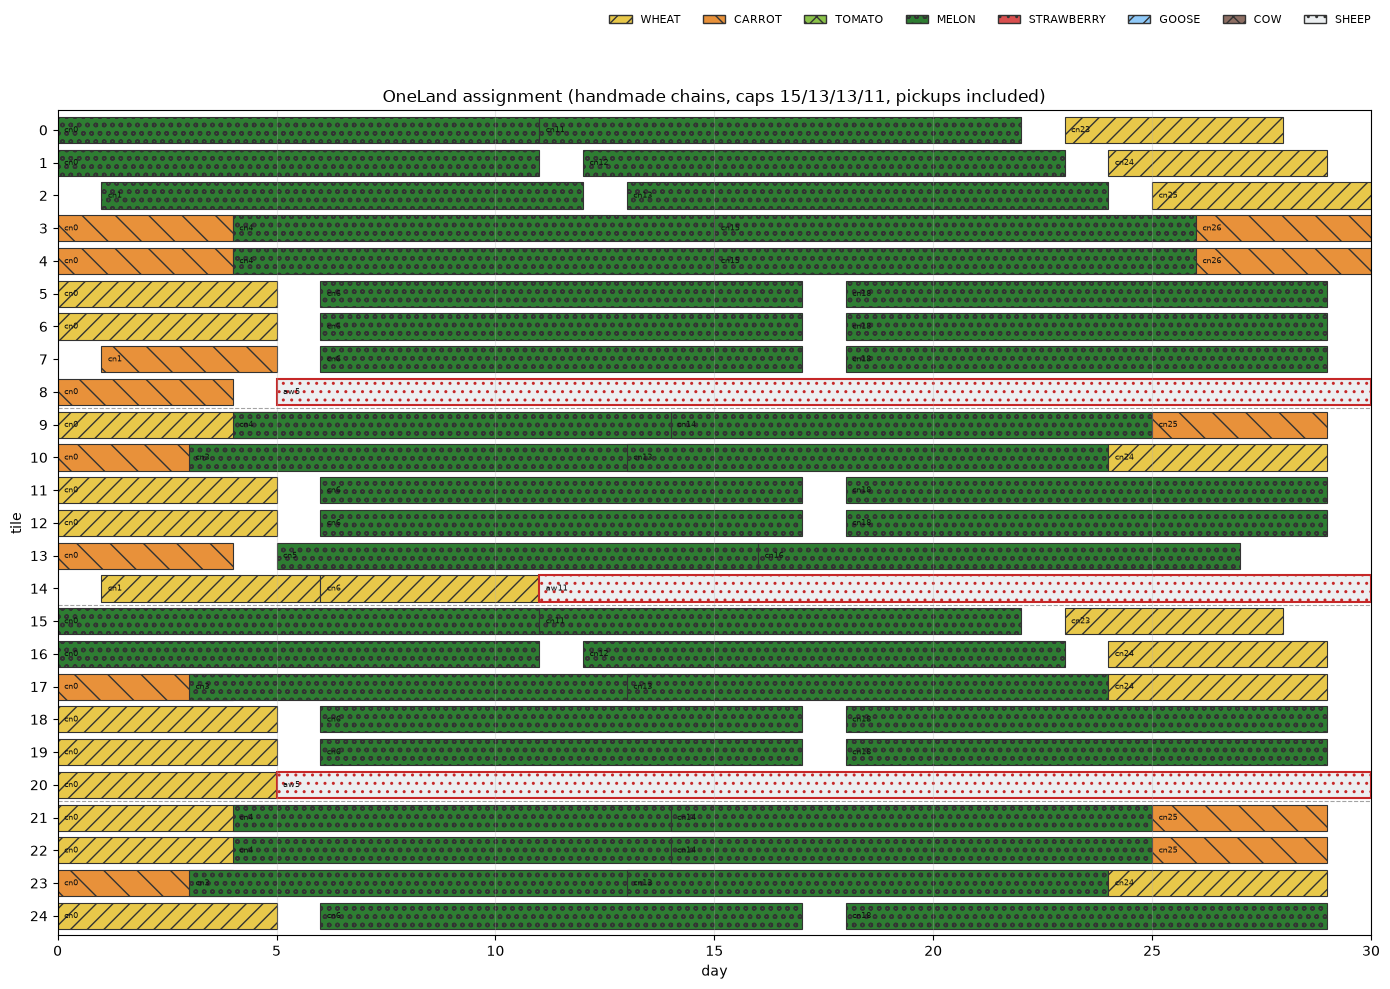

In [13]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

CROP_STYLE = {
    "WHEAT": {"color": "#e8c84a", "hatch": "//"},
    "CARROT": {"color": "#e8913a", "hatch": "\\"},
    "TOMATO": {"color": "#8bc34a", "hatch": "xx"},
    "MELON": {"color": "#2e7d32", "hatch": "oo"},
    "STRAWBERRY": {"color": "#d94f4f", "hatch": ".."},
}
ANIMAL_STYLE = {
    "GOOSE": {"color": "#90caf9", "hatch": "//"},
    "COW": {"color": "#8d6e63", "hatch": "xx"},
    "SHEEP": {"color": "#eceff1", "hatch": ".."},
}


def bar_style(segment):
    if segment["kind"] == "crop":
        st = dict(CROP_STYLE.get(segment["label"], {"color": "#999999", "hatch": ""}))
    else:
        st = dict(ANIMAL_STYLE.get(segment["label"], {"color": "#999999", "hatch": ""}))
    if segment["profile"] in ("with_fert", "with_care"):
        st["edgecolor"] = "#1565c0" if segment["kind"] == "crop" else "#c62828"
        st["linewidth"] = 1.5
    else:
        st.setdefault("edgecolor", "#333333")
        st.setdefault("linewidth", 0.8)
    return st


fig, ax = plt.subplots(figsize=(14, 10))
for row in selected:
    tile = row["tile"]
    chain = row["chain"]
    for seg in chain["segments"]:
        st = bar_style(seg)
        ax.barh(
            y=tile,
            width=seg["end_day"] - seg["start_day"],
            left=seg["start_day"],
            height=0.8,
            color=st["color"],
            hatch=st["hatch"],
            edgecolor=st["edgecolor"],
            linewidth=st["linewidth"],
        )
        tag = f"{seg['kind'][0]}{seg['profile'][0]}{seg['start_day']}"
        ax.text(seg["start_day"] + 0.15, tile, tag, va="center", fontsize=6, color="#111")

for yline in (8.5, 14.5, 20.5):
    ax.axhline(yline, color="#666666", linewidth=0.8, linestyle="--", alpha=0.6)

ax.set_xlabel("day")
ax.set_ylabel("tile")
ax.set_yticks(range(NUM_TILES))
ax.set_xlim(0, NUM_DAYS)
ax.set_ylim(-0.6, NUM_TILES - 0.4)
ax.set_title("OneLand assignment (handmade chains, caps 15/13/13/11, pickups included)")
ax.invert_yaxis()
legend_handles = [
    Patch(facecolor=st["color"], hatch=st["hatch"], edgecolor="#333333", label=name)
    for name, st in {**CROP_STYLE, **ANIMAL_STYLE}.items()
]
ax.grid(axis="x", alpha=0.3)
fig.tight_layout(rect=(0, 0, 1, 0.92))
fig.legend(
    handles=legend_handles,
    loc="upper right",
    bbox_to_anchor=(0.99, 0.99),
    bbox_transform=fig.transFigure,
    ncol=len(legend_handles),
    fontsize=8,
    frameon=False,
)
plt.show()

